In [79]:
%env XLA_PYTHON_CLIENT_PREALLOCATE=False

import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

"""
PKLs = []
PKL_titles = []
DIR = "./output/"
for file in os.listdir(DIR):
    if file.endswith(".pkl") and "merge" not in file:
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)"""


PKLs = []
PKL_titles = []
DIR = "./output_low_memory_10000/"
for file in os.listdir(DIR):
    if file.endswith(".pkl") and "merge" not in file:
        loaded = pickle.load(open(DIR+file, "rb"))
        loaded =  {'res': (None, None, None, loaded['res'][3], None, loaded['res'][5], loaded['res'][6], None, loaded['res'][8]), 'config':loaded['config']}
        if loaded['config']['prefix']=='None':
            PKLs.append(loaded)
            PKL_titles.append(str(file))
n = len(PKLs)
plt.rcParams['text.usetex'] = False

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


In [80]:
my_dims = np.concatenate([np.arange(1, 11, 1), [20, 50]])
my_dims = np.concatenate([np.arange(1, 11, 1), [20]])
my_dims = np.array([50, 100])
my_dims = np.array([1, 2, 3, 5, 10, 15, 30, 50, 75, 100])

idx_per_dim = {}
for dim in my_dims:
    idx_per_dim[dim] = [idx for idx in range(n) if PKLs[idx]['config']['dim'] == dim]
temperatures = {}
parameters = {}
critical_temperatures = []
for i, dim in enumerate(my_dims):
    temperatures[dim] = np.array([PKLs[idx]['res'][6] for idx in idx_per_dim[dim]]) 
    parameters[dim] = np.array([PKLs[idx]['res'][3].squeeze(axis=-1) for idx in idx_per_dim[dim]])

In [81]:
parameters[30]

array([[[0.  , 0.  , 0.  , 0.  , 0.82, 0.73, 0.  , 0.63, 0.99, 0.  ,
         0.67, 0.87, 0.92, 0.22, 0.74, 0.92, 0.99, 0.98, 0.96, 0.96,
         0.  , 0.75, 0.92, 0.96, 0.  , 0.66, 0.91, 0.96, 0.  , 0.78,
         0.96, 0.99, 0.  , 0.64, 0.88]],

       [[0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.99, 0.8 , 0.86, 0.88,
         0.9 , 0.99, 0.98, 0.  , 0.99, 0.79, 0.91, 0.46, 0.99, 0.  ,
         0.99, 0.98, 0.  , 0.81, 0.98, 0.97, 0.  , 0.78, 0.96, 0.97,
         0.98, 0.98, 0.  , 0.74, 0.97]],

       [[0.  , 0.  , 0.  , 0.  , 0.99, 0.  , 0.62, 0.99, 0.81, 0.88,
         0.9 , 0.91, 0.99, 0.77, 0.99, 0.  , 0.99, 0.44, 0.99, 0.  ,
         0.99, 0.98, 0.  , 0.79, 0.92, 0.96, 0.97, 0.97, 0.97, 0.97,
         0.98, 0.98, 0.98, 0.98, 0.  ]],

       [[0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.99, 0.8 , 0.99, 0.85,
         0.89, 0.91, 0.37, 0.85, 0.93, 0.94, 0.95, 0.95, 0.95, 0.96,
         0.  , 0.68, 0.9 , 0.95, 0.97, 0.97, 0.  , 0.8 , 0.98, 0.98,
         0.98, 0.45, 0.79, 0.96, 0.99]],

    

In [82]:
def last_zero(x):
    return np.where(np.cumsum(x)==0.)[0][-1] if len(np.where(np.cumsum(x)==0.)[0]) else None

In [83]:
critical_temperatures = np.zeros(shape=(len(my_dims), len(parameters[10])))
for idxdim, dim in enumerate(parameters.keys()):
    number_of_runs = len(parameters[dim])
    if number_of_runs:
        critical_temperatures[idxdim] = np.array([temperatures[dim][r,0][last_zero(parameters[dim][r,0])] for r in range(number_of_runs)])

In [84]:
for dim in idx_per_dim:
    print(len(idx_per_dim[dim]))

10
10
10
10
10
10
10
10
10
10


In [85]:
for idx in idx_per_dim[100]:
    if np.any(np.isnan(PKLs[idx]['res'][5])):
        print(idx)

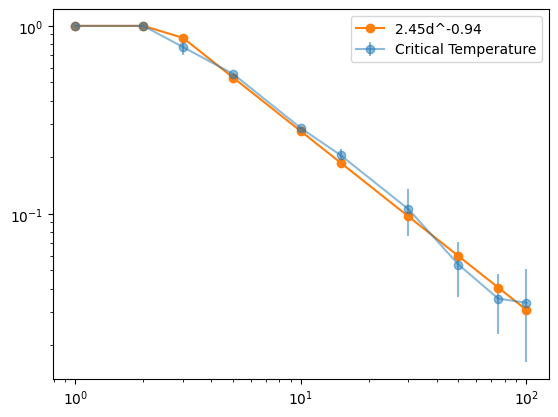

In [90]:
mean_critical_temperatures = critical_temperatures.mean(axis=-1)
log_mean_critical_temperatures = np.log(mean_critical_temperatures)

mask = (log_mean_critical_temperatures < 0)
filtered_log_temperatures = log_mean_critical_temperatures[mask]
filtered_dims = my_dims[mask]
filtered_log_dims = np.log(filtered_dims)
#performing linear regression
import scipy.stats as stats
slope, intercept, r_value, p_value, std_err = stats.linregress(filtered_log_dims, filtered_log_temperatures)
regression_line = np.exp(intercept) * filtered_dims**slope
filled_regression_line = np.concatenate([np.array((len(my_dims)-len(filtered_dims))*[1]), regression_line])

plt.errorbar(my_dims, mean_critical_temperatures, yerr=critical_temperatures.std(axis=-1), marker='o', label='Critical Temperature', alpha=0.5)
plt.loglog(my_dims, filled_regression_line, marker='o', label=rf'{str(np.exp(intercept))[:4]}d^{str(slope)[:5]}')
plt.legend()

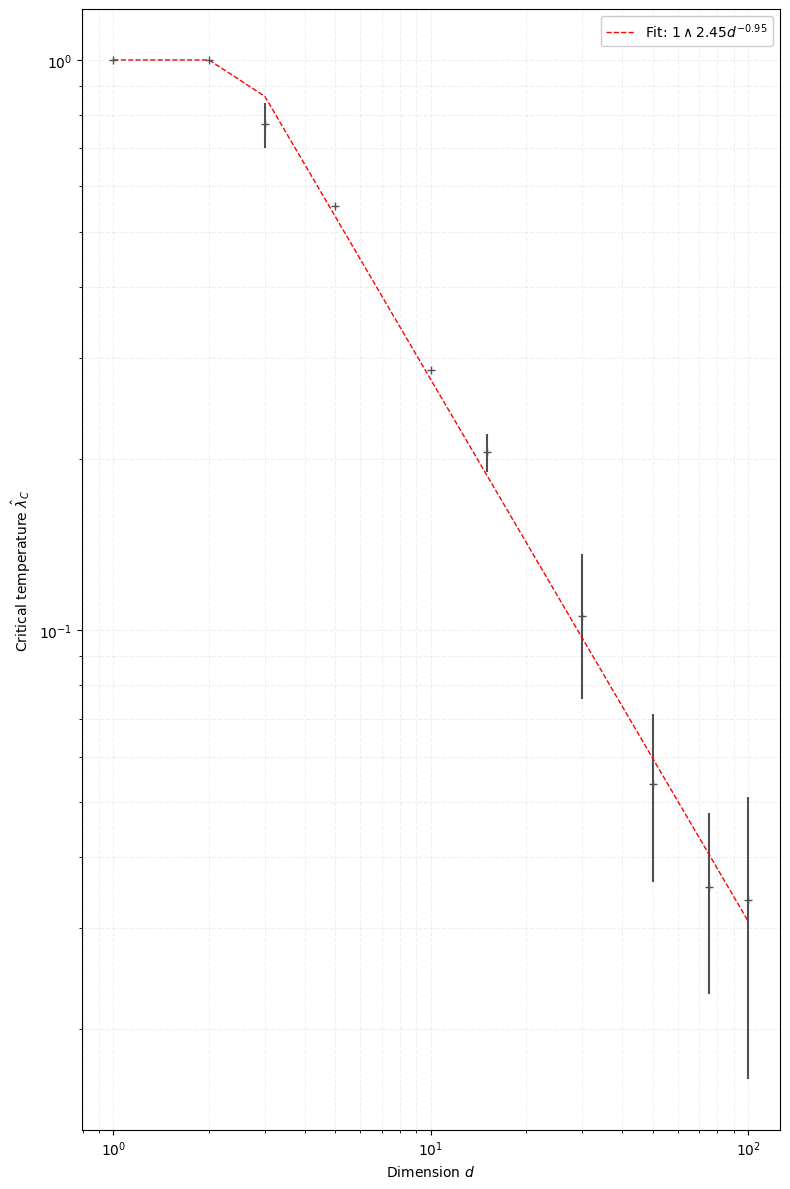

In [164]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Color scheme matching previous plots
colors = {
    'data': '#505050',      # Dark gray
    'fit': '#D55E00',       # Vermillion
    'error': '#505050'      # Medium gray for error bars
}
fig = plt.subplots(figsize=(8, 12))
# Calculate statistics
mean_critical_temperatures = critical_temperatures.mean(axis=-1)
log_mean_critical_temperatures = np.log(mean_critical_temperatures)

# Filter and perform regression
mask = (log_mean_critical_temperatures < 0)
filtered_log_temperatures = log_mean_critical_temperatures[mask]
filtered_dims = my_dims[mask]
filtered_log_dims = np.log(filtered_dims)

slope, intercept, r_value, p_value, std_err = stats.linregress(filtered_log_dims, filtered_log_temperatures)
regression_line = np.exp(intercept) * filtered_dims**slope
filled_regression_line = np.concatenate([np.array((len(my_dims)-len(filtered_dims))*[1]), regression_line])

# Main data plot with error bars
plt.errorbar(my_dims, mean_critical_temperatures, 
             yerr=critical_temperatures.std(axis=-1),
             fmt='+',
             color=colors['data'],
             elinewidth=1.5,)

# Regression line
regression_plot = plt.loglog(my_dims, filled_regression_line, 
                            color='red',
                            linewidth=1,
                            linestyle='--',
                            marker='',
                            label=rf'Fit: $1\wedge {np.exp(intercept):.2f}d^{{{slope:.2f}}}$')

# Highlight the fitted region
# plt.fill_between(filtered_dims, 
#                regression_line * 0.9, 
#                regression_line * 1.1,
#                color=colors['fit'],
#                alpha=0.1,
#                label='Fitted region')

# Formatting
plt.xlabel(r'Dimension $d$')
plt.ylabel(r'Critical temperature $\hat{\lambda}_C$')
plt.grid(True, which="both", linestyle='--', alpha=0.2)
plt.legend(framealpha=1, loc='best')

plt.tight_layout()
plt.savefig(DIR + "critical_temperature_scaling.pdf", 
           dpi=300, 
           bbox_inches='tight',
           format='pdf')




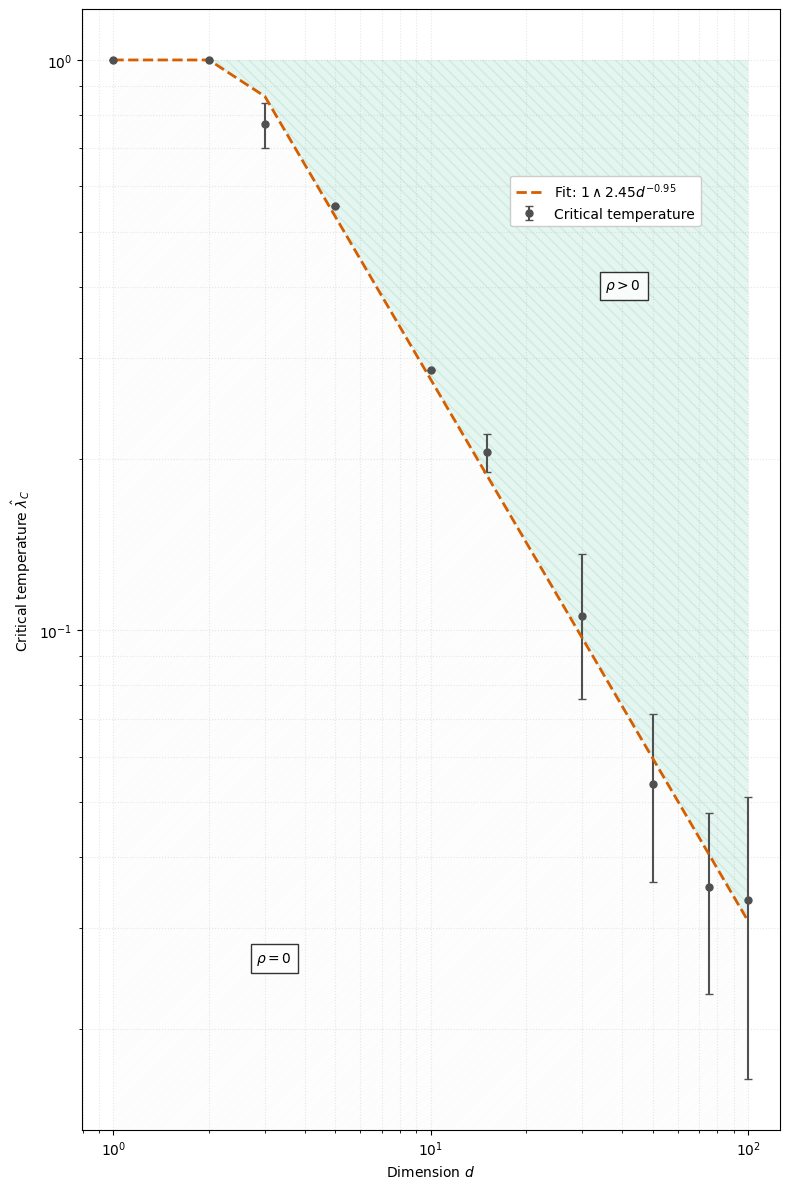

In [181]:

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Setup
fig, ax = plt.subplots(figsize=(8, 12))

# Color scheme
colors = {
    'data': '#505050',      # Dark gray
    'fit': '#D55E00',       # Vermillion (red)
    'active': '#029E73',    # Green (for ρ > 0 region)
    'inactive': '#F5F5F5'   # Light gray (for ρ = 0 region)
}

# Filter and perform regression
mask = (log_mean_critical_temperatures < 0)
filtered_log_temperatures = log_mean_critical_temperatures[mask]
filtered_dims = my_dims[mask]
filtered_log_dims = np.log(filtered_dims)

slope, intercept, r_value, p_value, std_err = stats.linregress(filtered_log_dims, filtered_log_temperatures)
regression_line = np.exp(intercept) * filtered_dims**slope
filled_regression_line = np.concatenate([np.array((len(my_dims)-len(filtered_dims))*[1]), regression_line])

# Using hatch patterns instead of solid fills:
ax.fill_between(my_dims, 0, filled_regression_line,
               color=colors['inactive'], alpha=0.1, hatch='///', linewidth=0)
ax.fill_between(my_dims, filled_regression_line, np.max(mean_critical_temperatures),
               color=colors['active'], alpha=0.1, hatch='\\\\\\', linewidth=0)
# Data points
ax.errorbar(my_dims, mean_critical_temperatures,
           yerr=critical_temperatures.std(axis=-1),
           fmt='o',
           color=colors['data'],
           markersize=5,
           capsize=3,
           label='Critical temperature')

# Regression line
ax.loglog(my_dims, filled_regression_line,
         color=colors['fit'],
         linewidth=2,
         linestyle='--',
         label=rf'Fit: $1\wedge {np.exp(intercept):.2f}d^{{{slope:.2f}}}$')

# Annotations
ax.text(0.25, 0.15, 
       r'$\rho = 0$ ',
       transform=ax.transAxes,
       bbox=dict(facecolor='white', alpha=0.8))
ax.text(0.75, 0.75, 
       r'$\rho > 0$ ',
       transform=ax.transAxes,
       bbox=dict(facecolor='white', alpha=0.8))

# Formatting
ax.set_xlabel(r'Dimension $d$')
ax.set_ylabel(r'Critical temperature $\hat{\lambda}_C$')
ax.grid(True, which="both", linestyle=':', alpha=0.3)
ax.legend(framealpha=1, bbox_to_anchor=(0.75, 0.80), loc='lower center') 

plt.tight_layout()
plt.savefig(DIR + "critical_temperature_boundary.pdf",
           dpi=150,
           bbox_inches='tight',
           format='pdf')

In [165]:
to_remove_dims = [100]
for d in to_remove_dims:
    for idx in idx_per_dim[d]:
        os.remove(DIR+PKL_titles[idx])

        

In [14]:
for i in range(n):
    if "vanish" in PKLs[i]['config']['prefix']:
        os.remove(DIR+PKL_titles[i])

In [111]:
parameters[dim].mean(axis=-1)

array([[0.7279999 ],
       [0.73085713],
       [0.7006667 ],
       [0.7256191 ],
       [0.7342857 ],
       [0.716     ],
       [0.71190476],
       [0.7110476 ],
       [0.67428565],
       [0.7253333 ]], dtype=float32)

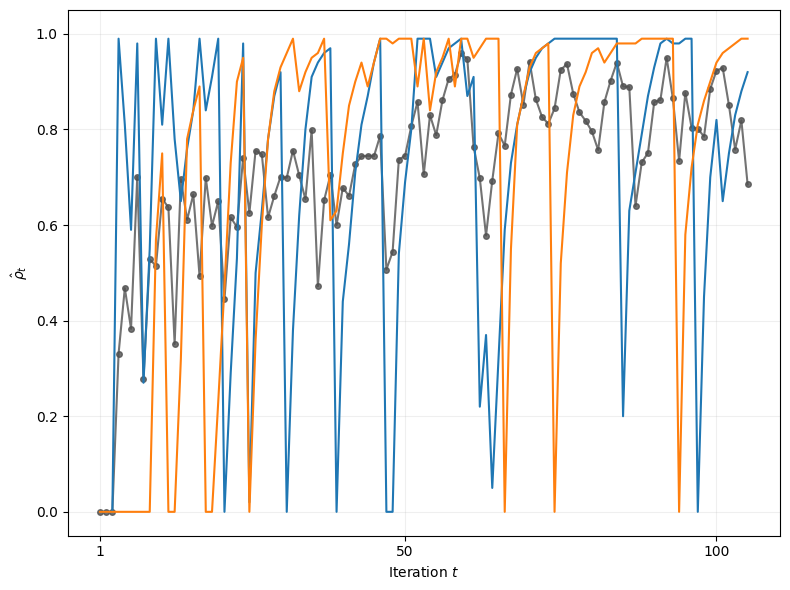

In [151]:
# Apply consistent styling
max_iter = 105  # Since you're using 1-105 on x-axis
colors = ['#505050']  # Using single color to match single dataset

fig, ax = plt.subplots(figsize=(8, 6))

y_mean = parameters[100].mean(axis=0).squeeze()
y_std = parameters[100].std(axis=0).squeeze()
lower_err = ((y_mean-y_std)>=0)*y_std + ((y_mean-y_std)<0)*(y_mean)
up_err = ((y_mean+y_std)<=1)*y_std + ((y_mean+y_std)>1)*(1-y_mean)
"""
plt.errorbar(x=np.arange(1, 106, 1), 
             y=y_mean, 
             yerr=[lower_err, up_err],
             color=colors[0],  # Using first gray color
             linewidth=1.5, 
             marker='o',
             markersize=4,
             capsize=3,
             alpha=0.8)  # Added slight transparency for elegance
"""
plt.plot(np.arange(1, 106), 
             y_mean, 
             color=colors[0],  # Using first gray color
             linewidth=1.5, 
             marker='o',
             markersize=4,
             alpha=0.8)

for run in parameters[100][:2]:
    plt.plot(np.arange(1, 106), 
             run.squeeze())

# Consistent formatting
plt.ylabel(r'$\hat{\rho}_t$')  # Update label as needed
plt.xlabel(r'Iteration $t$')  # Consistent with first plot

plt.ylim(-0.05, 1.05)

plt.xticks([1, 50, 100])  # Clean x-ticks every 10 iterations
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(DIR + "parameter_evolution.pdf",  # Update filename
           dpi=300, 
           bbox_inches='tight')

<ErrorbarContainer object of 3 artists>

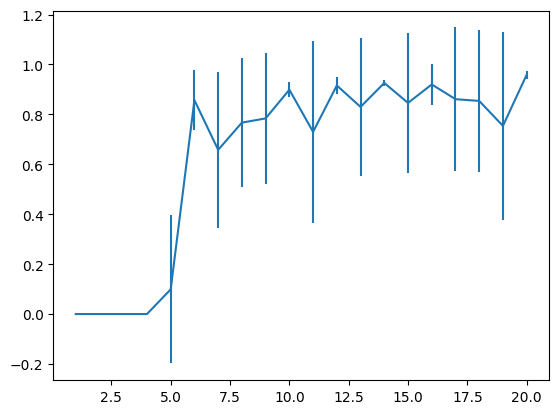

In [128]:
plt.errorbar(x=np.arange(1, 21, 1), y=parameters[15].mean(axis=0).squeeze(), yerr=parameters[15].std(axis=0).squeeze())